# **Modelo RNN**

## **Construcción del Dataset con Ventana Deslizante**

Para adaptar la serie de tiempo al formato requerido por los modelos RNN y LSTM, se utiliza la técnica de **ventana deslizante** con un tamaño de 24 horas (window_size = 24), dado que el consumo energético presenta una marcada estacionalidad diaria. Incorporar un ciclo completo de 24 horas como contexto permite capturar los patrones más relevantes: picos matutinos, valles nocturnos y diferencias entre horas laborales y no laborales.

El vector de entrada de cada observación está compuesto por:
- **24 rezagos** del consumo energético escalado (Value_scaled)
- **4 variables exógenas** del instante a predecir: hora del día, día de la semana, mes y tipo de clima

Los cortes temporales son:
- **Train:** datos previos a junio de 2025
- **Validación:** junio–noviembre 2025
- **Test:** diciembre 2025 en adelante

In [ ]:
window_size = 24
X, y, timestamps = [], [], []

vals  = df['Value_scaled'].values
hora  = df['hora'].values
dia   = df['dia_semana'].values
mes   = df['mes'].values
clima = df['clima_num'].values
idx   = df.index

for i in range(len(df) - window_size):
    rezagos = vals[i : i + window_size]
    exog    = [hora[i + window_size],
               dia[i + window_size],
               mes[i + window_size],
               clima[i + window_size]]
    X.append(np.concatenate([rezagos, exog]))
    y.append(vals[i + window_size])
    timestamps.append(idx[i + window_size])

X          = np.array(X)
y          = np.array(y)
timestamps = pd.DatetimeIndex(timestamps)

# Partición con cortes temporales exactos
val_start  = pd.Timestamp('2025-06-01')
test_start = pd.Timestamp('2025-12-01')

train_mask = timestamps < val_start
val_mask   = (timestamps >= val_start) & (timestamps < test_start)
test_mask  = timestamps >= test_start

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"X shape: {X.shape} → {window_size} rezagos + 4 exógenas = {X.shape[1]} inputs")
print(f"Train: {X_train.shape[0]:,} obs  ({timestamps[train_mask][0].date()} → {timestamps[train_mask][-1].date()})")
print(f"Val:   {X_val.shape[0]:,} obs  ({timestamps[val_mask][0].date()} → {timestamps[val_mask][-1].date()})")
print(f"Test:  {X_test.shape[0]:,} obs  ({timestamps[test_mask][0].date()} → {timestamps[test_mask][-1].date()})")

X shape: (175404, 28) → 24 rezagos + 4 exógenas = 28 inputs
Train: 124,051 obs  (2024-01-01 → 2025-05-31)
Val:   43,913 obs  (2025-06-01 → 2025-11-30)
Test:  7,440 obs  (2025-12-01 → 2025-12-31)


## **Reshaping de Datos para RNN y LSTM**

A diferencia del MLP, que recibe datos en formato 2D (samples, features), las redes recurrentes **RNN y LSTM requieren una estructura tridimensional**:

$$\textsf{(samples, timesteps, features)}$$

- samples: número de observaciones (ventanas)
- timesteps: número de pasos temporales = window_size (24)
- features: número de variables por paso = 1 (solo el rezago de consumo)

Las 4 variables exógenas se mantienen como contexto estático y se agregan en una capa separada más adelante. Sin embargo, para simplificar la arquitectura siguiendo el enfoque de la guía, se incorporan los 28 inputs directamente en la secuencia temporal, reshapeando a (samples, 28, 1).

> **Nota:** Este reshaping trata cada input (tanto rezagos como exógenas) como un paso temporal individual con 1 feature, lo que es equivalente a la estructura que exigen las capas RNN y LSTM de Keras.

In [ ]:
# Reshape: (samples, timesteps, features) = (n, 28, 1)
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_rnn   = X_val.reshape((X_val.shape[0],   X_val.shape[1],   1))
X_test_rnn  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

input_shape = (X_train_rnn.shape[1], X_train_rnn.shape[2])  # (28, 1)

print(f"Shape Train RNN: {X_train_rnn.shape}")
print(f"Shape Val   RNN: {X_val_rnn.shape}")
print(f"Shape Test  RNN: {X_test_rnn.shape}")
print(f"Input shape para RNN/LSTM: {input_shape}")

Shape Train RNN: (124051, 28, 1)
Shape Val   RNN: (43913, 28, 1)
Shape Test  RNN: (7440, 28, 1)
Input shape para RNN/LSTM: (28, 1)


## **Definición de Arquitecturas y Configuraciones de Dropout**

Se implementa una búsqueda exhaustiva sobre el mismo espacio de arquitecturas utilizado en el MLP:

- **Neuronas por capa:** 32, 64 y 128 unidades
- **Número máximo de capas:** 3 capas recurrentes apiladas
- **Dropout:** todas las combinaciones posibles por capa (activado/desactivado con tasa 0.5)

Esto genera **39 arquitecturas** × **configuraciones de dropout** = **258 modelos** evaluados para cada tipo de red (RNN y LSTM).

In [ ]:
neuronas      = [64]
max_capas     = 2
arquitecturas = []
for n in range(1, max_capas + 1):
    for comb in itertools.product(neuronas, repeat=n):
        arquitecturas.append(comb)

def dropout_configs(n_capas):
    for mask in range(2**n_capas):
        yield tuple(bool((mask >> i) & 1) for i in range(n_capas))

print(f"Total de arquitecturas a explorar: {len(arquitecturas)}")
print("Ejemplo de arquitecturas:")
for arch in arquitecturas[:5]:
    print(f"  {arch}")

Total de arquitecturas a explorar: 2
Ejemplo de arquitecturas:
  (64,)
  (64, 64)


## **Función de Diagnóstico: Test BDS**

La función (calcular_bds_completo) aplica el **test BDS** (Brock, Dechert y Scheinkman, 1996) sobre los residuos de predicción. Este test examina si los residuos son independientes e idénticamente distribuidos (i.i.d.), condición necesaria para considerar que el modelo capturó adecuadamente la estructura de la serie.

A diferencia del test de Ljung-Box (que detecta solo dependencias lineales), el BDS identifica **dependencias no lineales y estructuras caóticas**, siendo un diagnóstico más completo para modelos de deep learning.

**Hipótesis:**
- H₀: residuos son i.i.d. (ruido blanco)
- H₁: residuos presentan alguna forma de dependencia estructural

Un **p-valor > 0.05** indica que el modelo capturó la estructura relevante de la serie.

In [ ]:
def calcular_bds_completo(residuos):
    resultados_bds = {}
    # Estandarizar residuos
    residuos_std = (residuos - np.mean(residuos)) / (np.std(residuos) + 1e-8)

    if len(residuos_std) < 100 or np.std(residuos_std) < 1e-6:
        return None

    epsilons    = [0.5, 1.0, 1.5]
    dimensiones = [2, 3, 4]

    for eps_factor in epsilons:
        eps = eps_factor * np.std(residuos_std)
        for m in dimensiones:
            try:
                stat, pval = bds(residuos_std, max_dim=m, epsilon=eps)
                resultados_bds[f"m{m}_eps{eps_factor}"] = float(pval[-1])
            except:
                resultados_bds[f"m{m}_eps{eps_factor}"] = np.nan

    return resultados_bds


## **PARTE I — Modelo RNN (Recurrent Neural Network)**

### **Construcción del Modelo RNN**

La función construir_modelo_rnn implementa una red recurrente simple usando capas SimpleRNN. La principal diferencia con el MLP radica en el tipo de capa: mientras el MLP usa capas Dense (totalmente conectadas), la RNN usa capas recurrentes que mantienen un **estado oculto** entre pasos temporales, permitiendo capturar dependencias secuenciales en la serie.

Aspectos clave de la implementación:
- **return_sequences=True:** necesario en todas las capas excepto la última, para que cada capa recurrente pase la secuencia completa a la siguiente
- **Dropout (0.5):** aplicado según la máscara de configuración para regularización
- **Capa de salida Dense(1):** sin activación para regresión

In [ ]:
def construir_modelo_rnn(arquitectura, dropout_mask, input_shape):
    model = tf.keras.Sequential()

    for idx, units in enumerate(arquitectura):
        # return_sequences=True en todas las capas excepto la última
        return_seq = idx < len(arquitectura) - 1

        if idx == 0:
            model.add(tf.keras.layers.SimpleRNN(
                units,
                return_sequences=return_seq,
                input_shape=input_shape
            ))
        else:
            model.add(tf.keras.layers.SimpleRNN(
                units,
                return_sequences=return_seq
            ))

        if dropout_mask[idx]:
            model.add(tf.keras.layers.Dropout(0.5))

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )
    return model

# Verificar construcción con una arquitectura de ejemplo
model_test = construir_modelo_rnn((64, 32), (False, True), input_shape)
model_test.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 28, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

## **Entrenamiento y Evaluación — RNN**

El proceso de entrenamiento replica exactamente la metodología del MLP:

1. **Early Stopping** con patience=5 monitoreando val_loss, recuperando los mejores pesos
2. Máximo **30 épocas** con batch_size=32
3. Para cada modelo se calcula: **RMSE**, **MAPE**, **gap** (indicador de sobreajuste), **Ljung-Box** y **BDS**
4. La memoria de Keras se libera con clear_session() en cada iteración para evitar acumulación de grafos

> El entrenamiento de 258 configuraciones RNN puede tardar considerablemente. Se recomienda ejecutar en GPU (Colab T4/A100) o reducir el espacio de búsqueda ajustando neuronas y max_capas según la capacidad de cómputo disponible.

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

resultados_rnn = []
epochs = 30

for arch in arquitecturas:
    for dmask in dropout_configs(len(arch)):
        tf.keras.backend.clear_session()

        model = construir_modelo_rnn(arch, dmask, input_shape)

        history = model.fit(
            X_train_rnn, y_train,
            validation_data=(X_val_rnn, y_val),
            epochs=epochs,
            batch_size=32,
            callbacks=[early_stop],
            verbose=0
        )

        train_rmse = history.history['root_mean_squared_error']
        val_rmse   = history.history['val_root_mean_squared_error']
        best_val   = np.min(val_rmse)
        gap        = abs(train_rmse[-1] - best_val)

        y_pred_test = model.predict(X_test_rnn, verbose=0).flatten()
        test_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_test))
        mape        = mean_absolute_percentage_error(y_test + 1e-8, y_pred_test)
        residuos    = y_test - y_pred_test

        bds_dict  = calcular_bds_completo(residuos)
        try:
            lb        = acorr_ljungbox(residuos, lags=[10], return_df=True)
            lb_pvalue = lb['lb_pvalue'].values[0]
        except:
            lb_pvalue = np.nan

        resultados_rnn.append({
            'arquitectura':  arch,
            'dropout_mask':  dmask,
            'best_val_rmse': best_val,
            'test_rmse':     test_rmse,
            'mape':          mape,
            'lb_pvalue':     lb_pvalue,
            'bds':           bds_dict,
            'gap':           gap,
            'train_curve':   train_rmse,
            'val_curve':     val_rmse,
            'y_pred_test':   y_pred_test
        })

print(f"RNN — Modelos entrenados: {len(resultados_rnn)}")

RNN — Modelos entrenados: 6


## **Ranking y Selección del Mejor Modelo RNN**

Para seleccionar el mejor modelo se aplica un criterio **robusto de generalización**:

1. Se calcula el `gap_ratio = gap / best_val_rmse como indicador de sobreajuste relativo
2. Se filtran solo modelos con gap_ratio < 0.2 (diferencia de máximo 20% entre train y validación)
3. Entre los candidatos, se ordena por test_rmse ascendente
4. Se seleccionan los **Top 5** modelos más equilibrados

In [ ]:
df_rnn = pd.DataFrame([{
    'arquitectura':  r['arquitectura'],
    'dropout_mask':  r['dropout_mask'],
    'val_rmse':      r['best_val_rmse'],
    'test_rmse':     r['test_rmse'],
    'mape':          r['mape'],
    'lb_pvalue':     r['lb_pvalue'],
    'gap':           r['gap'],
    'bds_m2_eps0.5': r['bds']['m2_eps0.5'] if r['bds'] else np.nan,
    'bds_m2_eps1.0': r['bds']['m2_eps1.0'] if r['bds'] else np.nan,
    'bds_m2_eps1.5': r['bds']['m2_eps1.5'] if r['bds'] else np.nan,
    'bds_m3_eps0.5': r['bds']['m3_eps0.5'] if r['bds'] else np.nan,
    'bds_m3_eps1.0': r['bds']['m3_eps1.0'] if r['bds'] else np.nan,
    'bds_m3_eps1.5': r['bds']['m3_eps1.5'] if r['bds'] else np.nan,
    'bds_m4_eps0.5': r['bds']['m4_eps0.5'] if r['bds'] else np.nan,
    'bds_m4_eps1.0': r['bds']['m4_eps1.0'] if r['bds'] else np.nan,
    'bds_m4_eps1.5': r['bds']['m4_eps1.5'] if r['bds'] else np.nan,
} for r in resultados_rnn])

df_rnn['gap_ratio'] = df_rnn['gap'] / df_rnn['val_rmse']

# Filtro de generalización + ordenar por test RMSE
candidatos_rnn = df_rnn[df_rnn['gap_ratio'] < 0.2].sort_values('test_rmse')
top5_rnn       = candidatos_rnn.head(5)

print("=" * 60)
print("TOP 5 MODELOS RNN (ordenado por Test RMSE)")
print("=" * 60)
print(top5_rnn[['arquitectura', 'dropout_mask', 'val_rmse',
                'test_rmse', 'mape', 'lb_pvalue', 'gap_ratio']].to_string(index=False))

TOP 5 MODELOS RNN (ordenado por Test RMSE)
arquitectura   dropout_mask  val_rmse  test_rmse     mape    lb_pvalue  gap_ratio
       (64,)       (False,)  0.190488   0.219004 2.323583 4.926392e-07   0.051712
    (64, 64) (False, False)  0.191435   0.220334 2.879172 3.091509e-19   0.058002
    (64, 64)  (False, True)  0.193645   0.220794 3.048787 4.213451e-19   0.048908
    (64, 64)  (True, False)  0.194450   0.224445 2.890090 4.736749e-38   0.047946
       (64,)        (True,)  0.195690   0.225643 2.625223 2.237684e-40   0.038539


In [ ]:
# Mejor modelo RNN
mejor_idx_rnn = top5_rnn.index[0]
mejor_rnn     = resultados_rnn[mejor_idx_rnn]

print("\n--- MEJOR MODELO RNN ---")
print(f"Arquitectura: {mejor_rnn['arquitectura']}")
print(f"Dropout mask: {mejor_rnn['dropout_mask']}")
print(f"Val  RMSE:    {mejor_rnn['best_val_rmse']:.4f}")
print(f"Test RMSE:    {mejor_rnn['test_rmse']:.4f}")
print(f"MAPE:         {mejor_rnn['mape']*100:.2f}%")
print(f"LB p-valor:   {mejor_rnn['lb_pvalue']:.2e}")
print(f"Gap ratio:    {top5_rnn.loc[mejor_idx_rnn, 'gap_ratio']:.4f}")


--- MEJOR MODELO RNN ---
Arquitectura: (64,)
Dropout mask: (False,)
Val  RMSE:    0.1905
Test RMSE:    0.2190
MAPE:         232.36%
LB p-valor:   4.93e-07
Gap ratio:    0.0517


## **Visualización de Resultados — RNN**

### **Curvas de Aprendizaje — Top 5 Modelos RNN**

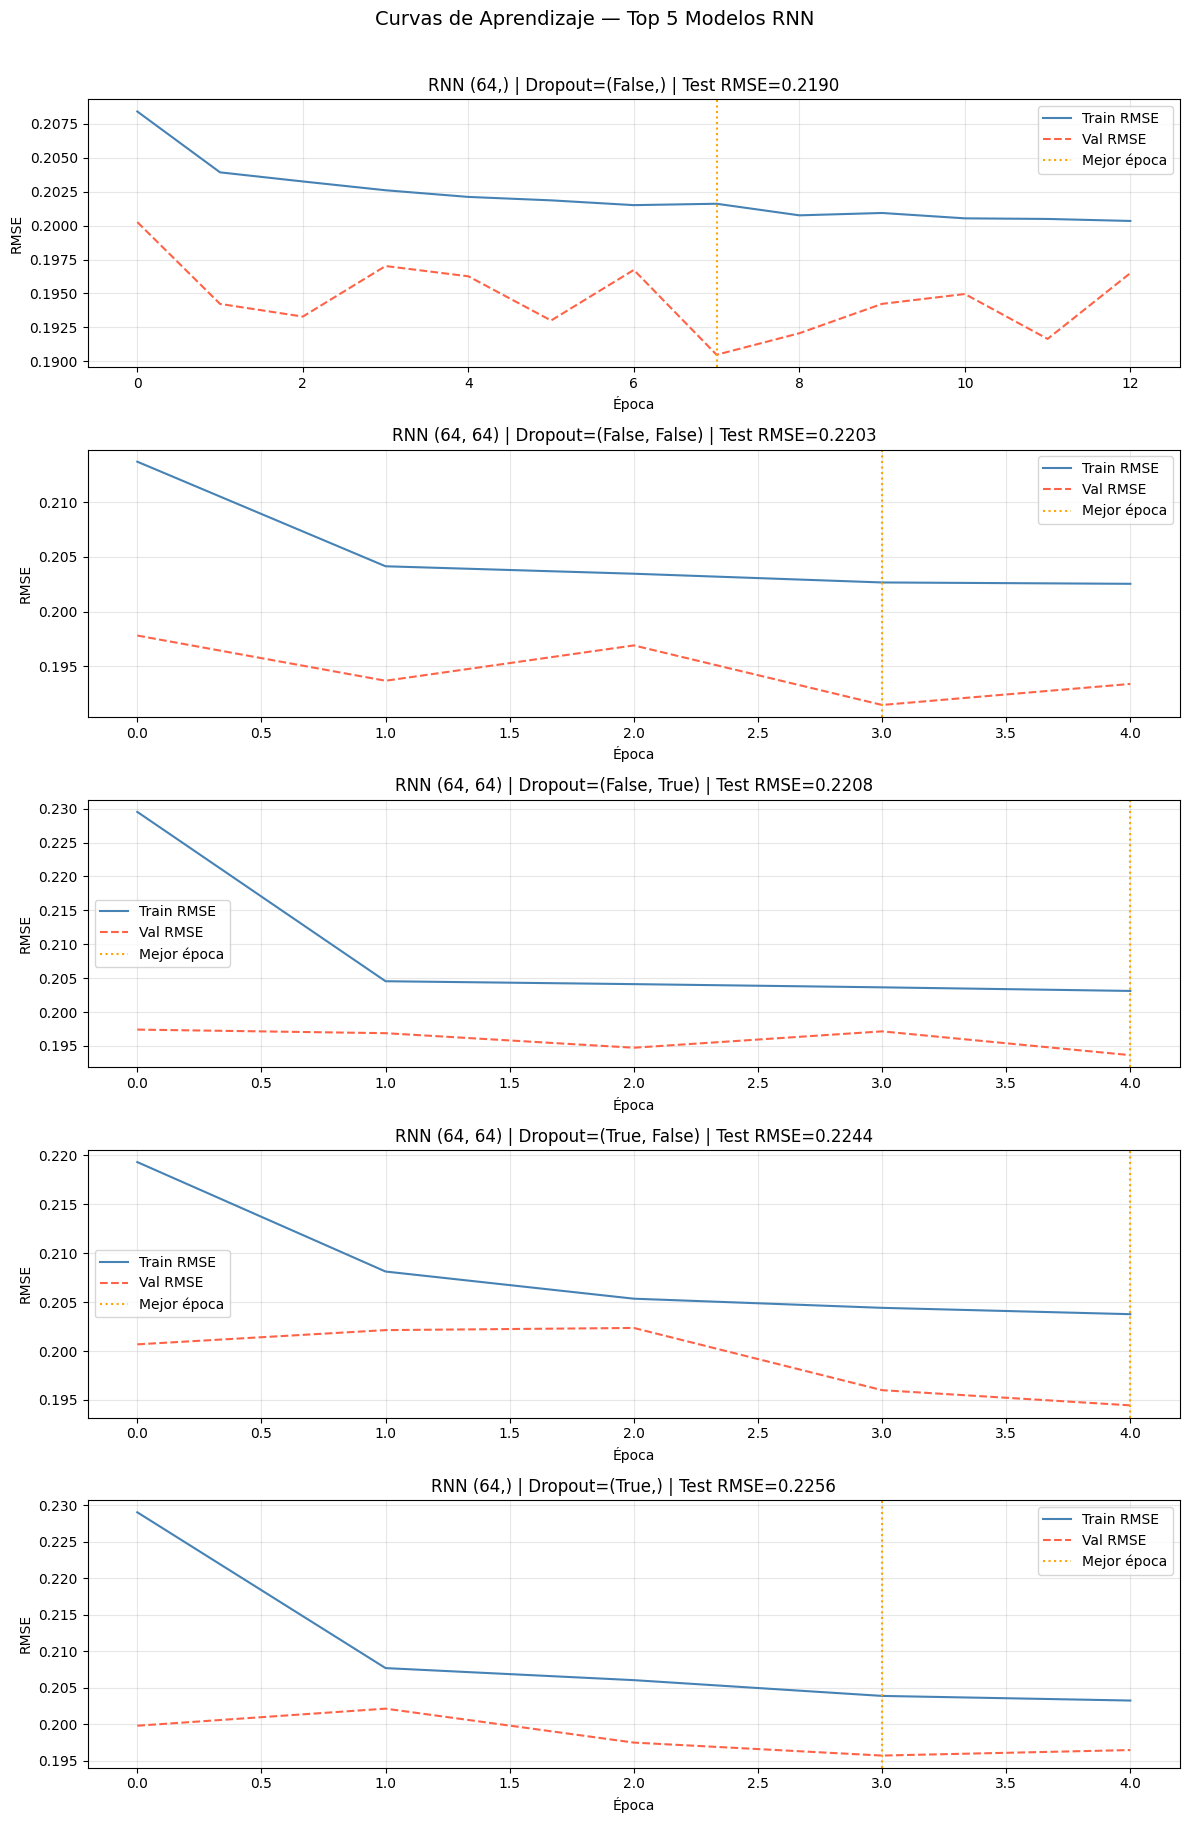

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 18))

for i, idx in enumerate(top5_rnn.index):
    r = resultados_rnn[idx]
    axes[i].plot(r['train_curve'], label='Train RMSE', color='steelblue')
    axes[i].plot(r['val_curve'],   label='Val RMSE',   color='tomato', linestyle='--')
    axes[i].axvline(x=np.argmin(r['val_curve']), color='orange',
                    linestyle=':', label='Mejor época')
    axes[i].set_title(f"RNN {r['arquitectura']} | Dropout={r['dropout_mask']} "
                      f"| Test RMSE={r['test_rmse']:.4f}")
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('RMSE')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — Top 5 Modelos RNN', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### **Consumo Real vs Predicho — Mejor Modelo RNN**

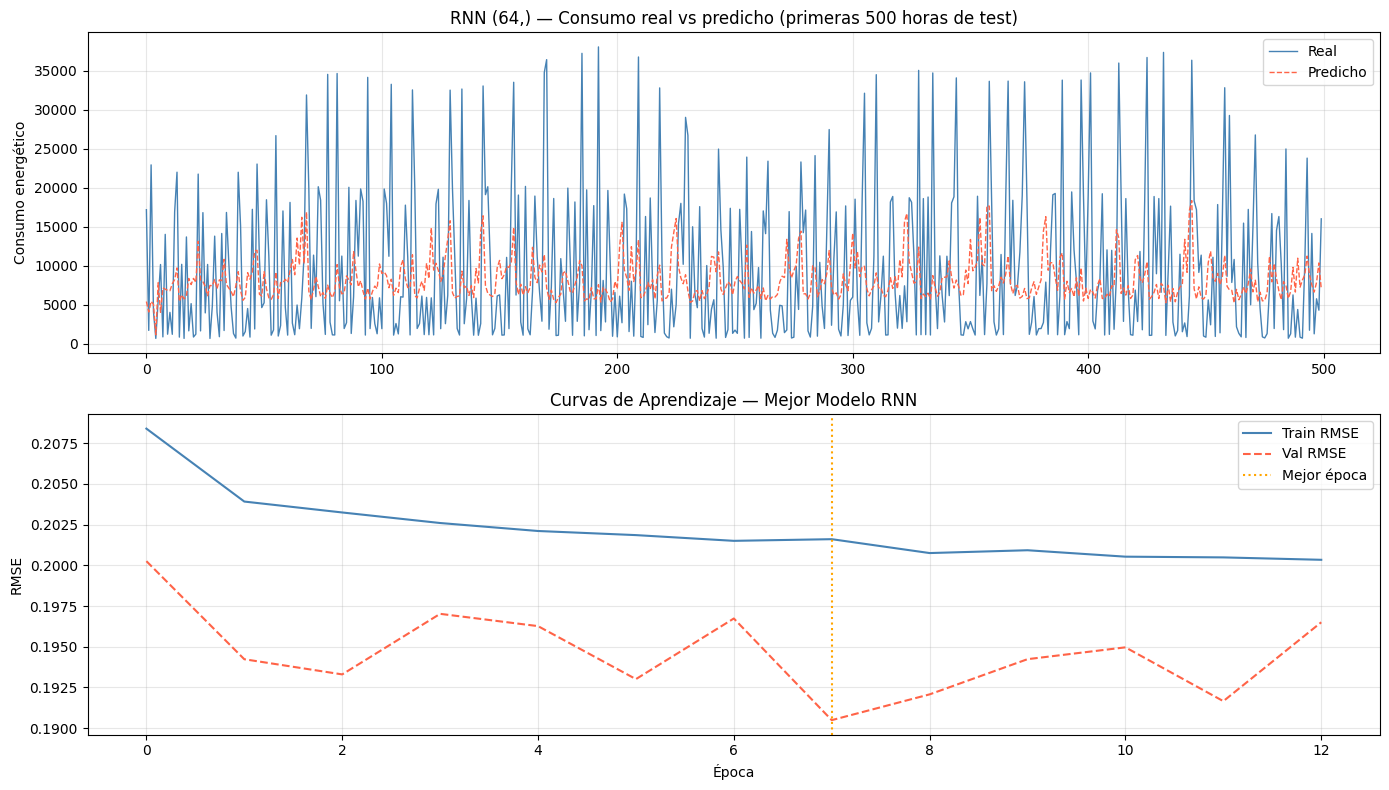

In [ ]:
# Invertir escala para valores reales de consumo
mejor_pred_rnn  = scaler.inverse_transform(mejor_rnn['y_pred_test'].reshape(-1, 1)).flatten()
real_values_rnn = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1 — primeras 500 horas del test
axes[0].plot(real_values_rnn[:500],  label='Real',     linewidth=1, color='steelblue')
axes[0].plot(mejor_pred_rnn[:500],   label='Predicho', linewidth=1,
             linestyle='--', color='tomato')
axes[0].set_title(f"RNN {mejor_rnn['arquitectura']} — Consumo real vs predicho (primeras 500 horas de test)")
axes[0].set_ylabel('Consumo energético')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2 — curvas de aprendizaje del mejor modelo
axes[1].plot(mejor_rnn['train_curve'], label='Train RMSE', color='steelblue')
axes[1].plot(mejor_rnn['val_curve'],   label='Val RMSE',   color='tomato', linestyle='--')
axes[1].axvline(x=np.argmin(mejor_rnn['val_curve']), color='orange',
                linestyle=':', label='Mejor época')
axes[1].set_title('Curvas de Aprendizaje — Mejor Modelo RNN')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### **Serie Completa — Train, Validación y Test**

In [ ]:
# Reentrenar el mejor modelo RNN para obtener predicciones en train y val
tf.keras.backend.clear_session()
model_rnn_best = construir_modelo_rnn(
    mejor_rnn['arquitectura'],
    mejor_rnn['dropout_mask'],
    input_shape
)
model_rnn_best.fit(
    X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=30, batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_pred_train_rnn = model_rnn_best.predict(X_train_rnn, verbose=0).flatten()
y_pred_val_rnn   = model_rnn_best.predict(X_val_rnn,   verbose=0).flatten()
y_pred_test_rnn  = model_rnn_best.predict(X_test_rnn,  verbose=0).flatten()

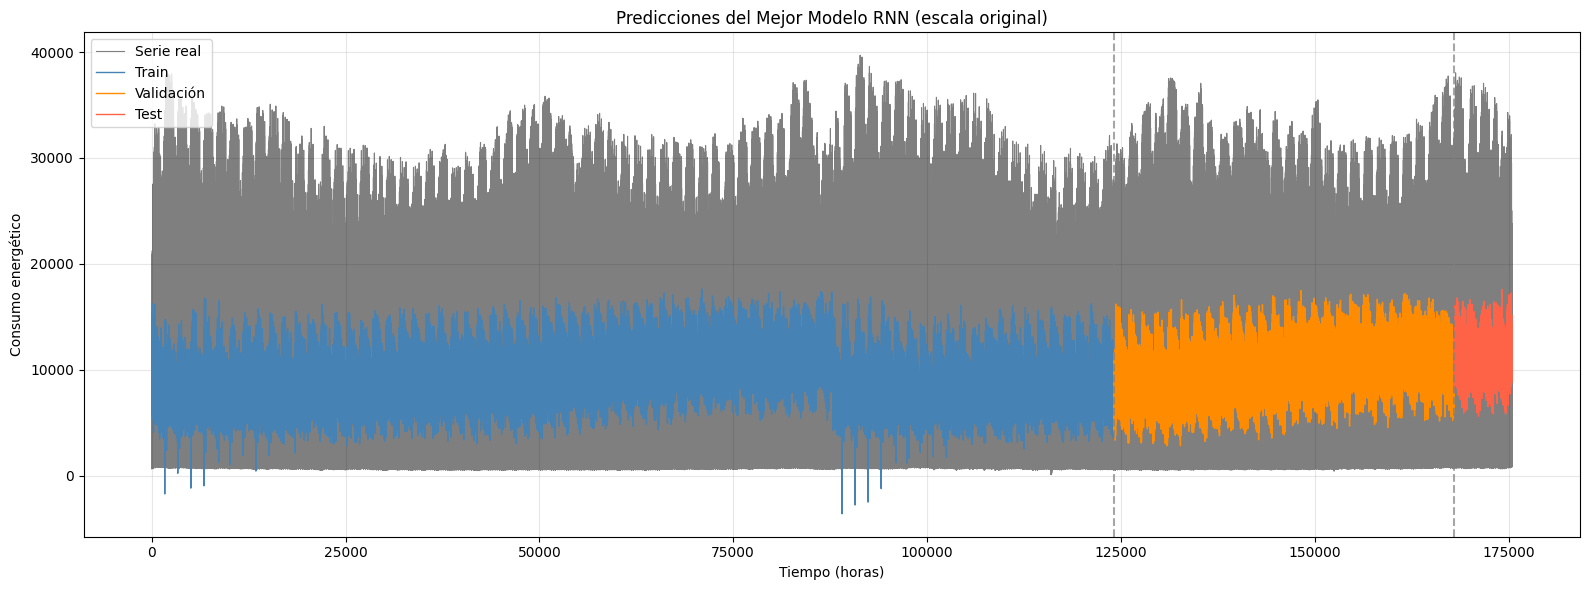

In [ ]:
def graficar_serie_completa(y_train, y_val, y_test,
                            y_pred_train, y_pred_val, y_pred_test,
                            scaler, window_size, titulo='Modelo'):

    # Invertir escala
    def inv(arr):
        return scaler.inverse_transform(arr.reshape(-1,1)).flatten()

    y_tr_r  = inv(y_train);      y_pr_tr_r = inv(y_pred_train)
    y_vl_r  = inv(y_val);        y_pr_vl_r = inv(y_pred_val)
    y_te_r  = inv(y_test);       y_pr_te_r = inv(y_pred_test)

    serie_real = np.concatenate([y_tr_r, y_vl_r, y_te_r])

    train_end = len(y_tr_r)
    val_end   = train_end + len(y_vl_r)

    plt.figure(figsize=(16, 6))
    plt.plot(serie_real, label='Serie real', color='black', alpha=0.5, linewidth=0.8)
    plt.plot(range(window_size, window_size + train_end),
             y_pr_tr_r, label='Train',      color='steelblue',  linewidth=1)
    plt.plot(range(window_size + train_end, window_size + val_end),
             y_pr_vl_r, label='Validación', color='darkorange',  linewidth=1)
    plt.plot(range(window_size + val_end, window_size + val_end + len(y_te_r)),
             y_pr_te_r, label='Test',       color='tomato',      linewidth=1)

    plt.axvline(window_size + train_end, linestyle='--', color='gray', alpha=0.7)
    plt.axvline(window_size + val_end,   linestyle='--', color='gray', alpha=0.7)

    plt.legend()
    plt.title(f'Predicciones del Mejor {titulo} (escala original)')
    plt.xlabel('Tiempo (horas)')
    plt.ylabel('Consumo energético')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

graficar_serie_completa(
    y_train, y_val, y_test,
    y_pred_train_rnn, y_pred_val_rnn, y_pred_test_rnn,
    scaler, window_size, titulo='Modelo RNN'
)